In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
import ast
df['job_skills'] = df['job_skills'].apply( lambda job_skills : ast.literal_eval(job_skills ) if pd.notna(job_skills) else job_skills )

<Axes: xlabel='job_month_name'>

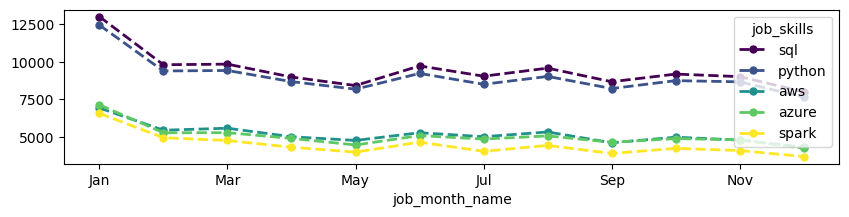

In [48]:

df_DE = df[  df['job_title_short'] == 'Data Engineer' ].copy()
df_DE['job_posted_month_no'] = df_DE['job_posted_date'].dt.month

# explode and pivote job skils

df_DE_explode = df_DE.explode('job_skills')
df_DE_pivote = df_DE_explode.pivot_table(
                index = 'job_posted_month_no' , 
                columns = 'job_skills' , 
                aggfunc = 'size', 
                fill_value = 0)

# order based on total skill count 
df_DE_pivote.loc['total'] = df_DE_pivote.sum()
df_DE_pivote= df_DE_pivote[df_DE_pivote.loc['total'].sort_values( ascending = False).index]
df_DE_pivote = df_DE_pivote.drop('total')


# use month name for plotting 
df_DE_pivote = df_DE_pivote.reset_index()

df_DE_pivote['job_month_name'] = df_DE_pivote['job_posted_month_no'].apply(lambda x : pd.to_datetime(x, format='%m').strftime('%b') )
df_DE_pivote= df_DE_pivote.set_index('job_month_name')
df_DE_pivote = df_DE_pivote.drop(columns='job_posted_month_no')

df_DE_pivote.iloc[: , :5 ].plot(
    kind='line' ,
    linewidth = 2,
    linestyle = '--',
    colormap = 'viridis',
    marker = 'o',
    markersize = 5,
    figsize = (10,2)
    )
